# Feature engineering pour `/recommend`

| | |
|---|---|
| **Objectif** | trouver, étape par étape, quelles variables aident la régression linéaire à prédire le rendement, puis comprendre la régression obtenue ; les modèles non linéaires sont comparés au notebook 14 |
| **Entrées** | `data/processed/recommend_training_dataset.csv` (notebook 06) ; coordonnées des pays tirées de `data/geo/ne_110m_admin_0_countries.geojson` |
| **Sorties** | 7 runs MLflow (`stage=feature_engineering`) ; aucun fichier |
| **Cible** | `yield_t_ha`, rendement en t/ha ; métrique principale : **RMSE** |
| **Protocole** | même protocole que le notebook 12 : apprentissage sur 1990-2012, validation temporelle 2008-2012 (chaque année prédite par un modèle appris sur les années précédentes) ; 2013 réservée au test final |
| **Features** | départ : la baseline du notebook 12 (`crop`, `year`, `avg_temp`, `rain_mm`, `pesticides_t`), `year` restant dans tous les jeux ; ajouts testés : `log_pesticides`, interactions avec `crop`, géographie (`lat_abs`, `geo_x`, `geo_y`, `geo_z`), `iso3`, conditions des 3 années précédentes (`temp_hist`, `log_pest_hist`) |

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

from agritech.evaluation import compare_cv_folds, errors_by_crop, predict_cv_folds
from agritech.geo import charger_coordonnees, plot_carte_categories
from agritech.interpretation import permutation_importance_by_family
from agritech.modeling import RunInfo, check_linear_rank, experiment_pipeline, run_experiment
from agritech.notification import notify
from agritech.recommend_config import (
    RECOMMEND_COLUMNS,
    RECOMMEND_CROPS,
    RECOMMEND_DATASET,
    RECOMMEND_FEATURES,
    RECOMMEND_GEOGRAPHY,
    RECOMMEND_HISTORICAL_CONDITIONS,
    RECOMMEND_LOG_CONDITIONS,
    RECOMMEND_ROWS,
    RECOMMEND_TARGET,
    RECOMMEND_TEST_YEAR,
    RECOMMEND_VALIDATION_YEARS,
)
from agritech.recommend_features import CropInteractions, add_historical_conditions, add_recommend_features
from agritech.tracking import run_tags, setup_mlflow
from agritech.training_data import load_dataset, temporal_cv, temporal_protocol_params, temporal_split

# Données et protocole

Même dataset, même découpage et mêmes 5 folds que le notebook 12. Les nouvelles variables sont calculées par
`agritech.recommend_features`, partagé avec les notebooks suivants et l'API. Elles n'utilisent jamais le rendement : on
peut les calculer avant le découpage, sans fuite.

In [2]:
df = load_dataset(RECOMMEND_DATASET, RECOMMEND_ROWS, RECOMMEND_COLUMNS, non_negative=[RECOMMEND_TARGET])

coordonnees = charger_coordonnees()
df = add_recommend_features(df, coordonnees)  # log des pesticides et géographie ; erreur si un pays n'a pas de coordonnées
df = add_historical_conditions(df)
assert sorted(df["crop"].unique()) == RECOMMEND_CROPS

print("\npays avec coordonnées :", df.loc[df["lat_abs"].notna(), "iso3"].nunique(), "sur", df["iso3"].nunique())
print("lignes sans historique (première année du pays) :", df["temp_hist"].isna().sum())
exemple = (df["iso3"] == "FRA") & (df["crop"] == "Wheat") & (df["year"] <= 1993)
df.loc[exemple, ["iso3", "year", "avg_temp", "temp_hist", "pesticides_t", "pest_hist"]].round(2)

fichier            : data/processed/recommend_training_dataset.csv
lignes x colonnes  : (16319, 8)
valeurs manquantes : 0
valeurs < 0        : 0 (yield_t_ha)

pays avec coordonnées : 115 sur 115
lignes sans historique (première année du pays) : 683


,iso3,year,avg_temp,temp_hist,pesticides_t,pest_hist
5130,FRA,1990,11.96,NaN,97701.0,NaN
5131,FRA,1991,10.60,11.96,103434.0,97701.00
5132,FRA,1992,11.15,11.28,85249.0,100567.50
5133,FRA,1993,10.70,11.24,91953.0,95461.33


In [3]:
VARIABLES_DERIVEES = ["log_pesticides", *RECOMMEND_GEOGRAPHY, "temp_hist", "log_pest_hist"]

X_train, X_test, y_train, y_test = temporal_split(
    df, RECOMMEND_FEATURES + VARIABLES_DERIVEES, RECOMMEND_TARGET, RECOMMEND_TEST_YEAR
)
print()
cv = temporal_cv(X_train["year"], RECOMMEND_VALIDATION_YEARS, RECOMMEND_TEST_YEAR)

total   : 16319 lignes, 1990-2013
X_train : (15624, 13), 1990-2012
X_test  : (695, 13), 2013, réservé à l'évaluation finale
y_train : (15624,)
y_test  : (695,)

validation 2008 : apprentissage 1990-2007 (12152 lignes) | 694 lignes évaluées
validation 2009 : apprentissage 1990-2008 (12846 lignes) | 692 lignes évaluées
validation 2010 : apprentissage 1990-2009 (13538 lignes) | 695 lignes évaluées
validation 2011 : apprentissage 1990-2010 (14233 lignes) | 695 lignes évaluées
validation 2012 : apprentissage 1990-2011 (14928 lignes) | 696 lignes évaluées


In [4]:
# mêmes tags et mêmes paramètres de protocole pour tous les runs de ce notebook
experience = setup_mlflow("recommend")
TAGS = run_tags(service="recommend", stage="feature_engineering", notebook="13_recommend_feature_engineering.ipynb")
PARAMS_PROTOCOLE = temporal_protocol_params(
    RECOMMEND_DATASET, RECOMMEND_TARGET, X_train, X_test, RECOMMEND_VALIDATION_YEARS, RECOMMEND_TEST_YEAR
)

expérience MLflow : oc_p12_agritech_recommend


## Fonctions du notebook

`evaluer` lance la validation temporelle d'un jeu, enregistre son run MLflow et vérifie, comme au notebook 12, que la
régression ne néglige aucune colonne. `comparer` compare des jeux à une référence **année par année** : écart moyen de
RMSE, années améliorées sur 5, MAE.

In [5]:
resultats, controles = {}, {}  # par jeu : scores par année de validation, et contrôle du rang


def evaluer(jeu, numeriques, interactions=None, categorielles=("crop",), avec_year=True, donnees=None,
            protocole=None, base=None, run=True):
    "Validation temporelle d'un jeu : run MLflow, scores par année et contrôle du rang. `year` est inclus par défaut."
    X, y, folds = donnees or (X_train, y_train, cv)
    variables = (["year"] if avec_year else []) + list(numeriques)
    nom = f"{jeu}_year" if avec_year else jeu
    # `base` : jeu auquel celui-ci ajoute des colonnes ; `replace` : une relance remplace le run au lieu de le dupliquer
    info = RunInfo(f"linear_regression_{nom}_cv", nom, TAGS, protocole or PARAMS_PROTOCOLE,
                   params={"base_feature_set": base or "none"}, replace=True) if run else None
    resultats[jeu], _ = run_experiment(
        LinearRegression(), X, y, folds, list(categorielles), variables,
        engineering=interactions, run=info, verbose=False, scale_numeric=True,
    )
    pipeline = experiment_pipeline(LinearRegression(), list(categorielles), variables, interactions, scale_numeric=True)
    controles[jeu] = check_linear_rank(pipeline, X, y, folds)


def comparer(reference, jeux):
    "Compare des jeux à une référence, année par année, et rappelle le contrôle du rang."
    noms = [reference] + jeux
    table = compare_cv_folds({jeu: resultats[jeu] for jeu in noms}, reference)
    table = table.rename(columns={"folds améliorés": "années améliorées"})
    rangs = pd.DataFrame(controles).T.loc[noms].rename(
        columns={"columns": "colonnes", "rank": "rang", "condition_number": "conditionnement"}
    )
    return table.join(rangs.astype({"colonnes": int, "rang": int})).round({"RMSE": 3, "écart moyen": 3, "MAE": 3, "conditionnement": 0})

# Référence

La baseline du notebook 12, `conditions_year` : `crop`, `avg_temp`, `rain_mm`, `pesticides_t` et `year`.

In [6]:
CONDITIONS_BRUTES = ["avg_temp", "rain_mm", "pesticides_t"]
evaluer("conditions", CONDITIONS_BRUTES, run=False)

reference = comparer("conditions", [])
assert reference.loc["conditions", "RMSE"] == 5.507  # même score que le notebook 12
reference

,RMSE,écart moyen,années améliorées,MAE,colonnes,rang,conditionnement
conditions,5.507,0.0,0/5,3.46,14,13,6.0


# Transformation des pesticides

`pesticides_t` est un tonnage national très étalé, de moins d'une tonne à plus d'un million : on le remplace par son
logarithme, `log_pesticides` = `log1p(pesticides_t)`.

In [7]:
CONDITIONS = RECOMMEND_LOG_CONDITIONS  # avg_temp, rain_mm, log_pesticides
evaluer("log_pesticides", CONDITIONS, base="conditions")

comparer("conditions", ["log_pesticides"])

,RMSE,écart moyen,années améliorées,MAE,colonnes,rang,conditionnement
conditions,5.507,0.000,0/5,3.460,14,13,6.0
log_pesticides,5.346,-0.161,5/5,3.368,14,13,7.0


**Observations :**

- Le logarithme améliore la RMSE des 5 années, et la MAE : `log_pesticides` remplace `pesticides_t` dans la suite.

# Interactions conditions × culture

La régression linéaire de départ considère que les conditions ont le même effet sur toutes les cultures.
On teste donc un effet différent selon la culture : pour chaque culture et chaque condition, une colonne qui
vaut la condition sur les lignes de cette culture et 0 ailleurs (`CropInteractions`).

In [8]:
INTERACTIONS_CULTURE = CropInteractions(CONDITIONS)  # une colonne par culture et par condition

# deux lignes de la France en 2012 : chaque colonne créée ne garde la température que pour sa culture
exemple = X_train[(X_train["iso3"] == "FRA") & (X_train["year"] == 2012) & X_train["crop"].isin(["Maize", "Potatoes"])]
display(INTERACTIONS_CULTURE.fit_transform(exemple)[["crop", "avg_temp", "Maize x avg_temp", "Potatoes x avg_temp"]].round(1))

evaluer("crop_x_conditions", CONDITIONS, INTERACTIONS_CULTURE, base="log_pesticides")
comparer("log_pesticides", ["crop_x_conditions"])

,crop,avg_temp,Maize x avg_temp,Potatoes x avg_temp
5032,Maize,11.2,11.2,0.0
5056,Potatoes,11.2,0.0,11.2


,RMSE,écart moyen,années améliorées,MAE,colonnes,rang,conditionnement
log_pesticides,5.346,0.000,0/5,3.368,14,13,7.0
crop_x_conditions,4.995,-0.351,5/5,3.081,44,40,84.0


**Observations :**

- Un effet différent selon la culture améliore nettement les 5 années : `crop_x_conditions` sert de base à la suite.

# Contexte géographique

Chaque pays reçoit les coordonnées de son point-étiquette Natural Earth, fixes dans le temps (les colonnes population et
PIB du fichier, récentes, ne sont pas utilisées) :

- `lat_abs` : latitude absolue, la distance à l'équateur ;
- `geo_x`, `geo_y`, `geo_z` : position sur le globe ; contrairement à la longitude, deux pays voisins ont toujours des
  valeurs proches.

La géographie est ajoutée à `crop_x_conditions`, telle quelle puis avec un effet différent selon la culture.

pays appariés : 115 sur 115
corrélation entre lat_abs et avg_temp, par pays : -0.86


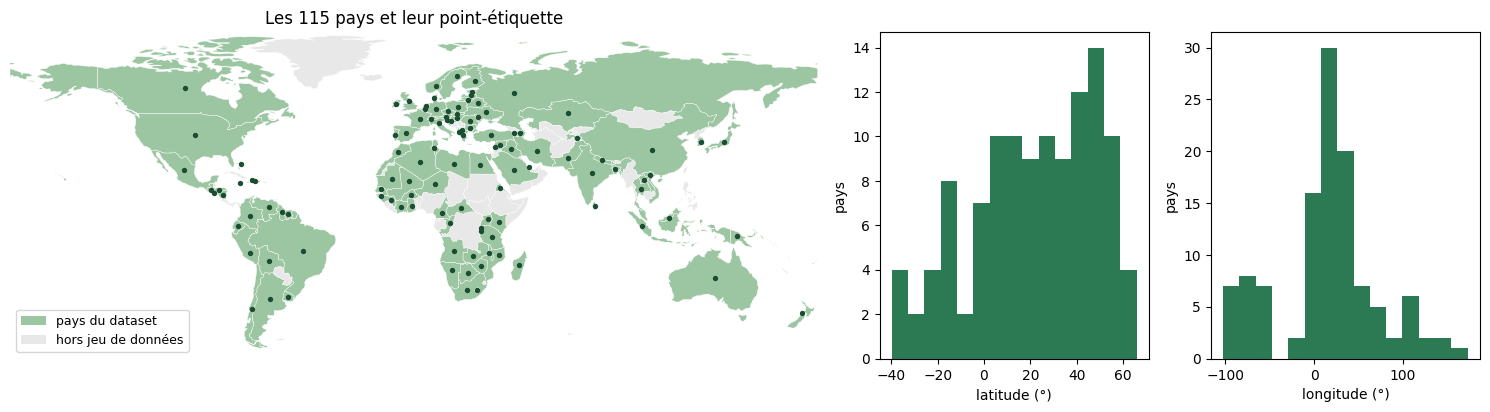

In [9]:
pays = pd.DataFrame(coordonnees, index=["longitude", "latitude"]).T.reindex(sorted(X_train["iso3"].unique()))
assert pays.notna().all().all() and len(pays) == 115
print(f"pays appariés : {len(pays)} sur {X_train['iso3'].nunique()}")

temperature = X_train.groupby("iso3")["avg_temp"].mean()
print(f"corrélation entre lat_abs et avg_temp, par pays : {pays['latitude'].abs().corr(temperature):.2f}")

figure, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [3, 1, 1]})
plot_carte_categories({code: "pays du dataset" for code in pays.index}, {"pays du dataset": "#9cc5a1"},
                      titre="Les 115 pays et leur point-étiquette", ax=axes[0])
axes[0].scatter(pays["longitude"], pays["latitude"], s=8, color="#1b4d33", zorder=3)
for axe, colonne in zip(axes[1:], ["latitude", "longitude"]):
    axe.hist(pays[colonne], bins=15, color="#2c7a53")
    axe.set_xlabel(f"{colonne} (°)")
    axe.set_ylabel("pays")
plt.tight_layout()
plt.show()

In [10]:
GEOGRAPHIE = RECOMMEND_GEOGRAPHY  # lat_abs, geo_x, geo_y, geo_z
INTERACTIONS_CULTURE_GEO = CropInteractions(CONDITIONS + GEOGRAPHIE)  # conditions et géographie, par culture

evaluer("geography", CONDITIONS + GEOGRAPHIE, INTERACTIONS_CULTURE, base="crop_x_conditions")
evaluer("crop_x_geography", CONDITIONS + GEOGRAPHIE, INTERACTIONS_CULTURE_GEO, base="crop_x_conditions")

comparer("crop_x_conditions", ["geography", "crop_x_geography"])

,RMSE,écart moyen,années améliorées,MAE,colonnes,rang,conditionnement
crop_x_conditions,4.995,0.000,0/5,3.081,44,40,84.0
geography,4.851,-0.144,5/5,3.025,48,44,92.0
crop_x_geography,4.673,-0.323,5/5,2.871,88,80,206.0


**Observations :**

- La géographie améliore les 5 années, et davantage avec un effet différent selon la culture.
- `lat_abs` est très liée à la température (−0,86 entre pays) mais apporte une information en plus : elle résume des différences entre pays tempérés et tropicaux, pas un effet de la latitude elle-même.

## Nouvelle référence

`crop_x_geography` devient notre **régression linéaire de référence** : **RMSE 4,67 t/ha** contre **5,51 t/ha** pour la baseline.

# Comparaison avec le pays

Le notebook 12 a montré que le pays (`iso3`) aide beaucoup la régression. On l'ajoute à la baseline et à
`crop_x_geography`.

In [11]:
evaluer("conditions_country", CONDITIONS_BRUTES, categorielles=("crop", "iso3"), run=False)
evaluer("crop_x_geography_country", CONDITIONS + GEOGRAPHIE, INTERACTIONS_CULTURE_GEO, categorielles=("crop", "iso3"),
        base="crop_x_geography")

comparaison_pays = comparer("conditions", ["crop_x_geography", "conditions_country", "crop_x_geography_country"])
assert comparaison_pays.loc["conditions_country", "RMSE"] == 4.531  # même score que le notebook 12
comparaison_pays

,RMSE,écart moyen,années améliorées,MAE,colonnes,rang,conditionnement
conditions,5.507,0.000,0/5,3.460,14,13,6.0
crop_x_geography,4.673,-0.834,5/5,2.871,88,80,206.0
conditions_country,4.531,-0.976,5/5,3.009,129,126,223.0
crop_x_geography_country,3.975,-1.532,5/5,2.633,203,189,238.0


**Observations :**

- La baseline avec pays fait un peu mieux que `crop_x_geography` (4,53 contre 4,67 t/ha), et les deux gains se cumulent
  en grande partie : 3,98 t/ha avec les deux.
- Mais `iso3` revient à reconnaître chaque pays, et tous les pays évalués ici sont déjà connus du modèle : il reste
  évalué à part.

# Conditions historiques

On vérifie si les conditions des 3 années précédentes, connues au moment de la recommandation, permettent de prédire aussi bien que les conditions de l’année à prédire, qui ne sont pas encore connues. Chaque étape ne change qu'une chose : d'abord les lignes, puis les conditions.
```
crop_x_geography                RMSE 4,673
  │ mêmes lignes, avec historique
  ▼
crop_x_geography_same_rows      RMSE 4,664
  │ température et pesticides :
  │ moyenne des 3 années précédentes
  ▼
history                         RMSE 4,644
```

In [12]:
avec_historique = X_train["temp_hist"].notna().to_numpy()
X_hist, y_hist = X_train[avec_historique], y_train[avec_historique]
cv_hist = temporal_cv(X_hist["year"], RECOMMEND_VALIDATION_YEARS, RECOMMEND_TEST_YEAR, verbose=False)
PARAMS_HISTORIQUE = temporal_protocol_params(
    RECOMMEND_DATASET, RECOMMEND_TARGET, X_hist, X_test, RECOMMEND_VALIDATION_YEARS, RECOMMEND_TEST_YEAR
)
print(f"lignes avec historique : {len(X_hist)} sur {len(X_train)}")
print(f"lignes de validation   : {sum(len(v) for _, v in cv_hist)} sur {sum(len(v) for _, v in cv)}")

CONDITIONS_HISTORIQUES = RECOMMEND_HISTORICAL_CONDITIONS  # temp_hist, rain_mm, log_pest_hist

# Pour une comparaison équitable, on réévalue d'abord crop_x_geography
# uniquement sur les lignes qui ont un historique, puis on remplace
# les conditions de l'année par celles calculées sur les années précédentes.
evaluer("crop_x_geography_same_rows", CONDITIONS + GEOGRAPHIE, INTERACTIONS_CULTURE_GEO, donnees=(X_hist, y_hist, cv_hist),
        run=False)
evaluer("history", CONDITIONS_HISTORIQUES + GEOGRAPHIE, CropInteractions(CONDITIONS_HISTORIQUES + GEOGRAPHIE),
        donnees=(X_hist, y_hist, cv_hist), protocole=PARAMS_HISTORIQUE, base="crop_x_geography")

comparer("crop_x_geography_same_rows", ["history"])

lignes avec historique : 14941 sur 15624
lignes de validation   : 3472 sur 3472


,RMSE,écart moyen,années améliorées,MAE,colonnes,rang,conditionnement
crop_x_geography_same_rows,4.664,0.00,0/5,2.861,88,80,206.0
history,4.644,-0.02,3/5,2.852,88,80,210.0


**Observations :**

- Sur les mêmes lignes, les conditions historiques font à peu près comme celles de l'année. Elles ont l'avantage d'être
  connues avant la recommandation : le notebook 14 les teste avec les modèles non linéaires.

# Rôle de l'année

`year` est dans tous les jeux. Pour mesurer son apport, la baseline et `crop_x_geography` sont recalculés sans elle.

In [13]:
evaluer("conditions_no_year", CONDITIONS_BRUTES, avec_year=False, run=False)
evaluer("crop_x_geography_no_year", CONDITIONS + GEOGRAPHIE, INTERACTIONS_CULTURE_GEO, avec_year=False, run=False)

pd.concat([comparer("conditions_no_year", ["conditions"]), comparer("crop_x_geography_no_year", ["crop_x_geography"])])

,RMSE,écart moyen,années améliorées,MAE,colonnes,rang,conditionnement
conditions_no_year,5.604,0.000,0/5,3.404,13,12,6.0
conditions,5.507,-0.096,5/5,3.460,14,13,6.0
crop_x_geography_no_year,4.761,0.000,0/5,2.782,87,79,206.0
crop_x_geography,4.673,-0.088,5/5,2.871,88,80,206.0


**Une tendance par culture.** Avec `crop × year`, chaque culture a sa propre évolution dans le temps.

In [14]:
evaluer("crop_trends", CONDITIONS + GEOGRAPHIE, CropInteractions(CONDITIONS + GEOGRAPHIE + ["year"]), base="crop_x_geography")

comparer("crop_x_geography", ["crop_trends"])

,RMSE,écart moyen,années améliorées,MAE,colonnes,rang,conditionnement
crop_x_geography,4.673,0.000,0/5,2.871,88,80,206.0
crop_trends,4.607,-0.066,5/5,2.777,98,89,4445.0


**Observations :**

- `year` améliore la RMSE des 5 années pour les deux jeux, mais pas la MAE.
- Une tendance par culture améliore encore les 5 années. Mais le modèle servira pour des années plus récentes que
  l'apprentissage : prolonger dix tendances pourrait changer le classement des cultures sans que les conditions
  changent. Cette variante n'est pas gardée pour la suite.

# Analyse de la régression linéaire obtenue

`crop_x_geography` : la culture, `year`, les trois conditions et la géographie, avec un effet différent selon la
culture. C'est la meilleure régression observée sans identifiant de pays.

## Erreurs par année et par culture

,RMSE,écart moyen,années améliorées,MAE,colonnes,rang,conditionnement
conditions,5.507,0.000,0/5,3.460,14,13,6.0
log_pesticides,5.346,-0.161,5/5,3.368,14,13,7.0
crop_x_conditions,4.995,-0.512,5/5,3.081,44,40,84.0
crop_x_geography,4.673,-0.834,5/5,2.871,88,80,206.0


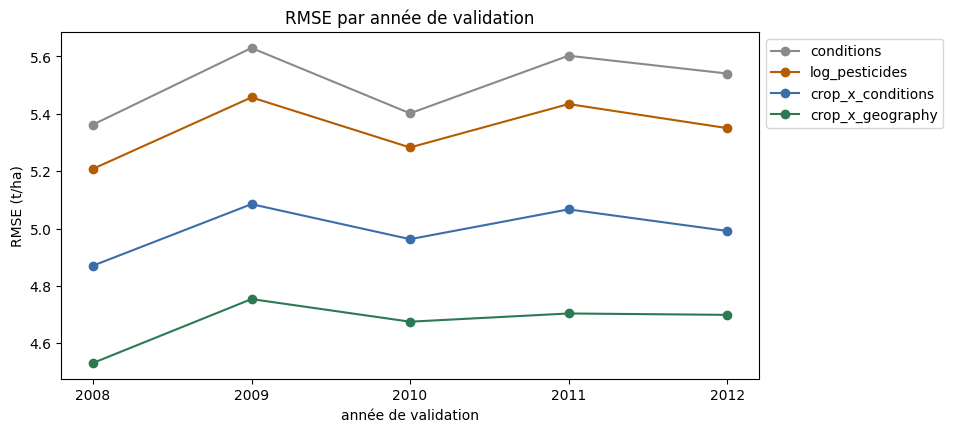

,2008,2009,2010,2011,2012
log_pesticides,-0.154,-0.172,-0.119,-0.168,-0.190
crop_x_conditions,-0.492,-0.544,-0.439,-0.536,-0.549
crop_x_geography,-0.831,-0.875,-0.726,-0.898,-0.841


In [15]:
CHEMIN = ["conditions", "log_pesticides", "crop_x_conditions", "crop_x_geography"]
display(comparer("conditions", CHEMIN[1:]))

rmse_annees = pd.DataFrame({jeu: resultats[jeu]["rmse"].to_numpy() for jeu in CHEMIN}, index=RECOMMEND_VALIDATION_YEARS)

COULEURS = dict(zip(CHEMIN, ["#8a8a8a", "#b35c00", "#3b6ea8", "#2c7a53"]))
figure, axe = plt.subplots(figsize=(9, 4.5))
for jeu in CHEMIN:
    axe.plot(rmse_annees[jeu], color=COULEURS[jeu], marker="o", label=jeu)
axe.set_xticks(RECOMMEND_VALIDATION_YEARS)
axe.set_xlabel("année de validation")
axe.set_ylabel("RMSE (t/ha)")
axe.set_title("RMSE par année de validation")
axe.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

# écart à la baseline, année par année
rmse_annees[CHEMIN[1:]].sub(rmse_annees["conditions"], axis=0).T.round(3)

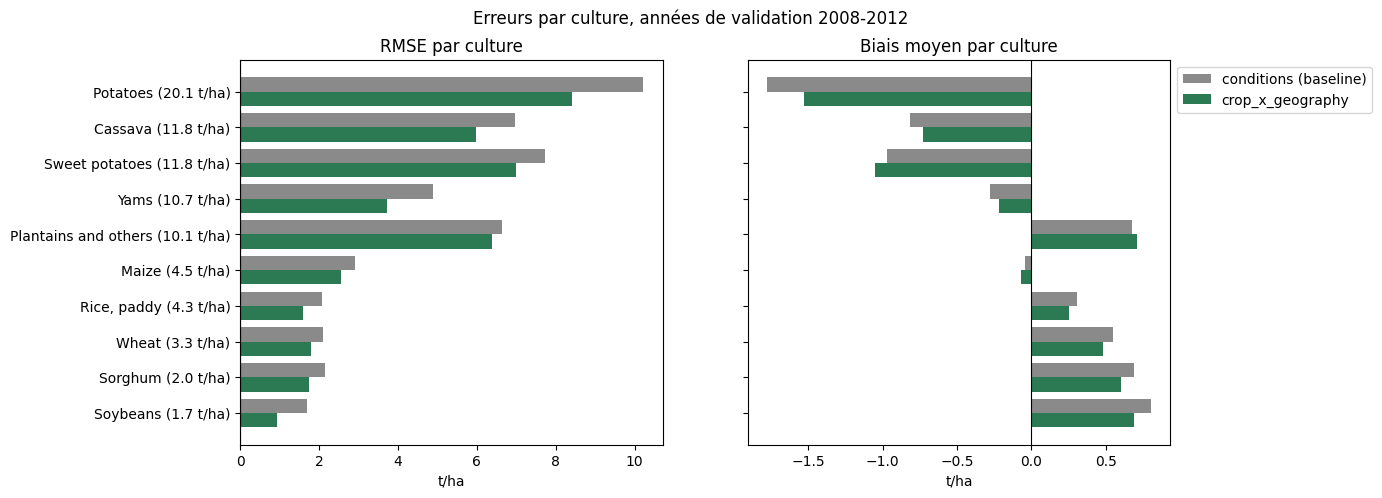

conditions                           crop_x_geography  \
                           RMSE   MAE biais RMSE relative             RMSE   
crop                                                                         
Soybeans                   1.70  1.27  0.80          0.99             0.93   
Sorghum                    2.14  1.49  0.69          1.06             1.74   
Wheat                      2.11  1.72  0.55          0.63             1.79   
Rice, paddy                2.06  1.66  0.31          0.48             1.58   
Maize                      2.91  2.19 -0.04          0.65             2.56   
Plantains and others       6.63  4.69  0.67          0.66             6.38   
Yams                       4.88  4.01 -0.28          0.45             3.71   
Sweet potatoes             7.72  5.99 -0.97          0.66             7.00   
Cassava                    6.98  5.19 -0.82          0.59             5.97   
Potatoes                  10.21  7.83 -1.78          0.51             8.41   

                                                
                       MAE biais RMSE relative  
crop                                            
Soybeans              0.81  0.69          0.54  
Sorghum               1.25  0.60          0.86  
Wheat                 1.50  0.48          0.54  
Rice, paddy           1.27  0.25          0.37  
Maize                 1.82 -0.07          0.57  
Plantains and others  4.70  0.71          0.63  
Yams                  2.47 -0.22          0.35  
Sweet potatoes        5.05 -1.05          0.60  
Cassava               4.56 -0.73          0.51  
Potatoes              6.50 -1.53          0.42

In [16]:
NUMERIQUES_GEO = ["year"] + CONDITIONS + GEOGRAPHIE
PIPELINES = {
    "conditions": experiment_pipeline(LinearRegression(), ["crop"], ["year"] + CONDITIONS_BRUTES, scale_numeric=True),
    "crop_x_geography": experiment_pipeline(LinearRegression(), ["crop"], NUMERIQUES_GEO, INTERACTIONS_CULTURE_GEO,
                                            scale_numeric=True),
}

# prédictions de validation : chaque année est prédite par un modèle appris sur les seules années précédentes
validations = {}
for jeu, pipeline in PIPELINES.items():
    predictions = predict_cv_folds(pipeline, X_train, y_train, cv)
    validation = X_train.loc[predictions.index, ["year", "crop"]].assign(rendement=y_train.loc[predictions.index], prediction=predictions)
    validations[jeu] = validation.assign(erreur=validation["prediction"] - validation["rendement"])
    # mêmes folds que les évaluations : les RMSE par année doivent être identiques
    rmse_par_annee = np.sqrt((validations[jeu]["erreur"] ** 2).groupby(validations[jeu]["year"]).mean())
    assert np.allclose(rmse_par_annee, rmse_annees[jeu])

baseline, regression = (errors_by_crop(v["rendement"], v["prediction"], v["crop"]) for v in validations.values())
libelles = [f"{c} ({r:.1f} t/ha)" for c, r in baseline["rendement moyen"].items()]
positions = np.arange(len(baseline))
figure, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for axe, colonne, titre in [(axes[0], "RMSE", "RMSE par culture"), (axes[1], "biais", "Biais moyen par culture")]:
    axe.barh(positions + 0.2, baseline[colonne], height=0.4, color="#8a8a8a", label="conditions (baseline)")
    axe.barh(positions - 0.2, regression[colonne], height=0.4, color="#2c7a53", label="crop_x_geography")
    axe.axvline(0, color="black", linewidth=0.8)
    axe.set_xlabel("t/ha")
    axe.set_title(titre)
axes[0].set_yticks(positions, libelles)
axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
figure.suptitle("Erreurs par culture, années de validation 2008-2012")
plt.show()

pd.concat({"conditions": baseline, "crop_x_geography": regression}, axis=1).drop(columns=["n", "rendement moyen"], level=1).round(2)

**Observations :**

- `crop_x_geography` gagne 0,7 à 0,9 t/ha sur la baseline chaque année : le gain ne repose pas sur une seule année.
- L'erreur baisse pour les 10 cultures.
- Le biais reste présent malgré les nouvelles variables : les cultures à faible rendement restent surestimées, la pomme
  de terre, la patate douce et le manioc sous-estimés. On verra avec les modèles non linéaires s'il peut être réduit.

## Corrélations

Entre les variables de `crop_x_geography` et le rendement, sur 1990-2012.

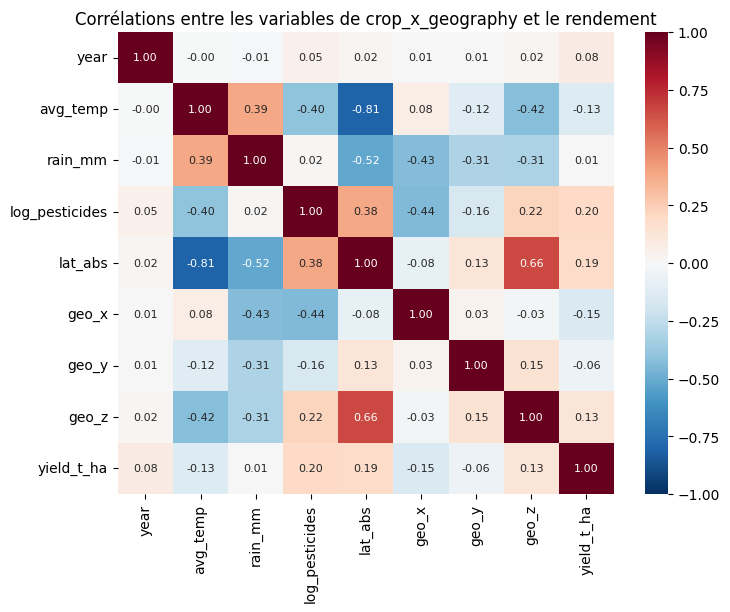

In [17]:
correlations = X_train[NUMERIQUES_GEO].assign(yield_t_ha=y_train).corr()

figure, axe = plt.subplots(figsize=(8, 6))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, annot_kws={"size": 8}, ax=axe)
axe.set_title("Corrélations entre les variables de crop_x_geography et le rendement")
plt.show()

**Observations :**

- `avg_temp` et `lat_abs` sont très liées (−0,81) : la géographie redit en partie le climat.
- Une variable peut sembler peu liée au rendement quand on regarde toutes les cultures ensemble, mais devenir utile
  quand on distingue les cultures : la corrélation seule ne dit pas si une variable aide le modèle.

## Importance par permutation

On mélange une information (la culture, la géographie ou une condition) dans l'année de validation et on regarde de
combien la RMSE augmente. `year` n'est pas testée : elle est la même pour toute l'année de validation.

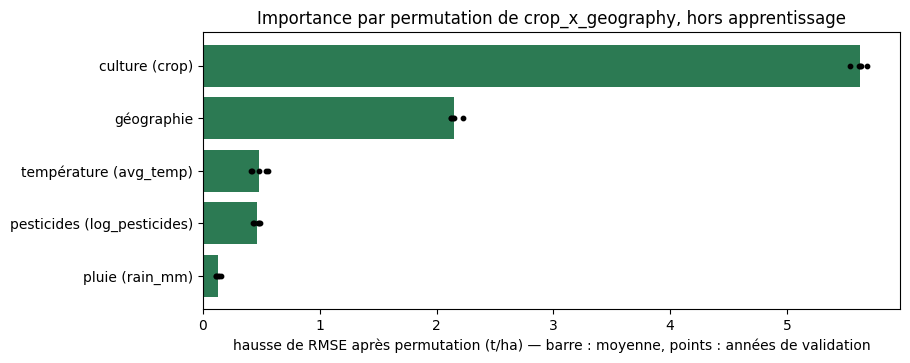

annee,2008,2009,2010,2011,2012,moyenne
famille,,,,,,
culture (crop),5.63,5.69,5.54,5.62,5.64,5.62
géographie,2.22,2.12,2.14,2.15,2.12,2.15
température (avg_temp),0.54,0.42,0.56,0.41,0.48,0.48
pesticides (log_pesticides),0.49,0.43,0.44,0.47,0.48,0.46
pluie (rain_mm),0.13,0.11,0.16,0.13,0.11,0.13


In [18]:
FAMILLES = {
    "culture (crop)": ["crop"],
    "géographie": GEOGRAPHIE,
    "température (avg_temp)": ["avg_temp"],
    "pluie (rain_mm)": ["rain_mm"],
    "pesticides (log_pesticides)": ["log_pesticides"],
}

importances = permutation_importance_by_family(
    PIPELINES["crop_x_geography"], X_train[["crop"] + NUMERIQUES_GEO], y_train, cv, FAMILLES,
    n_repeats=10, fold_labels=RECOMMEND_VALIDATION_YEARS,
)
par_annee = importances.pivot(index="famille", columns="fold", values="hausse de RMSE").rename_axis(columns="annee")
par_annee = par_annee.loc[par_annee.mean(axis=1).sort_values().index]

figure, axe = plt.subplots(figsize=(9, 3.6))
axe.barh(par_annee.index, par_annee.mean(axis=1), color="#2c7a53")
for annee in par_annee.columns:
    axe.scatter(par_annee[annee], par_annee.index, color="black", s=10, zorder=3)
axe.set_xlabel("hausse de RMSE après permutation (t/ha) — barre : moyenne, points : années de validation")
axe.set_title("Importance par permutation de crop_x_geography, hors apprentissage")
plt.show()

par_annee.assign(moyenne=par_annee.mean(axis=1)).sort_values("moyenne", ascending=False).round(2)

**Observations :**

- La culture compte le plus, de loin, puis la géographie, loin devant la température, les pesticides et la pluie. C'est
  stable d'une année à l'autre.
- Ces résultats valent pour cette régression linéaire. Les autres modèles pourront utiliser les variables différemment.

# Conclusion

In [19]:
# récapitulatif de toutes les évaluations de validation temporelle du notebook
recapitulatif = pd.DataFrame({jeu: folds[["rmse", "mae", "r2"]].mean() for jeu, folds in resultats.items()}).T
recapitulatif.columns = ["RMSE", "MAE", "R²"]
recapitulatif.join(pd.DataFrame(controles).T[["columns", "rank"]].astype(int).rename(columns={"columns": "colonnes", "rank": "rang"})).round(3)

,RMSE,MAE,R²,colonnes,rang
conditions,5.507,3.460,0.574,14,13
log_pesticides,5.346,3.368,0.598,14,13
crop_x_conditions,4.995,3.081,0.649,44,40
geography,4.851,3.025,0.669,48,44
crop_x_geography,4.673,2.871,0.693,88,80
conditions_country,4.531,3.009,0.712,129,126
crop_x_geography_country,3.975,2.633,0.778,203,189
crop_x_geography_same_rows,4.664,2.861,0.694,88,80
history,4.644,2.852,0.697,88,80
conditions_no_year,5.604,3.404,0.559,13,12


**Ce qui aide clairement la régression linéaire**

- `log_pesticides` à la place de `pesticides_t` ;
- les interactions conditions × culture : un effet différent de chaque condition selon la culture ;
- la géographie (`lat_abs`, position sur le globe), surtout avec un effet différent selon la culture.

Meilleure régression linéaire sans identifiant de pays : `crop_x_geography`, **RMSE ≈ 4,67 t/ha** contre 5,51 pour la
baseline.

**À retenir pour la suite**

- `iso3` améliore encore les scores, mais revient à reconnaître le pays : il reste une comparaison à part ;
- les conditions historiques font à peu près comme celles de l'année, et sont connues avant la recommandation ;
- `year` aide ; une tendance par culture aussi, mais elle serait risquée à prolonger.

Un biais par culture reste présent ; le notebook 14 vérifie s'il diminue avec les modèles non linéaires.

In [20]:
notify(
    "Agritech /recommend",
    f"Feature engineering terminé — crop_x_geography : RMSE {recapitulatif.loc['crop_x_geography', 'RMSE']:.2f} t/ha,"
    f" R² {recapitulatif.loc['crop_x_geography', 'R²']:.3f} (validation temporelle)",
)